# GEO 371T/391: Climate Data - Spring 2026
# Assignment 7
# Observational Comparison of Cumulative Precipitation Metrics

*Developed by Cameron Cummins: 2/24/2026*

*Updated by Geeta Persad: 2/25/2026*

**In this notebook, we will focus on the data analysis needed to answer the core question of the observational comparison step of our class project: What is the historical distribution of cumulative precipitation from observations and how well do they agree?**

**To do this, we will map, over our 30-year historical baseline period (1985-2014) for 1-day, 3-day, and 5-day cumulative precipitation:**
1. The median precipitation amount
2. The 5th percentile precipitation amount
3. The 95th percentile precipitation amount
4. The 30-year trend

**You will have the following tasks in this assignment, some of which we will work on in lecture and some of which you will complete outside of class time:**

- Task 1: Think through how we ensure we’re comparing apples to apples across the observations
- Task 2: Given 95th percentile map, add a figure caption
- Task 3: Given 95th percentile map code, generate 5th percentile and median maps and add associated figure captions
- Task 4: Given trend map, add a figure caption
- Task 5: Create a regional map, based on a region of your choice, and write associated figure caption.
- GRAD SECTION ONLY – TASK 6: Design your own additional analysis (e.g. difference of metrics or percentiles), write the code to generate the map of that analysis, and write the associated figure caption.


# Step 1: Setting up the data and packages

The below block of code does the following:
1. Imports the necessary packages
2. Defines some functions that we'll use later on to map the metrics onto our hydrobasins
3. Reads in the processed MSWEP, MSWEP_nogauge, NOAA CPC, and ERA5 data

Run the below block of code.

## Task 1: Comparing Apples to Apples

Notice that we have to multiply the ERA5 data by 24 in the below code block. In this markdown box, briefly describe your guess as to why we have to do this.

In [1]:
%%time
import xarray as xr
import geopandas as gpd
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib
matplotlib.style.use('fast')


class WinkelTripel(ccrs._WarpedRectangularProjection):
	"""
	Winkel-Tripel projection implementation for Cartopy
	"""

	def __init__(self, central_longitude=0.0, central_latitude=0.0, globe=None):
		globe = globe or ccrs.Globe(semimajor_axis=ccrs.WGS84_SEMIMAJOR_AXIS)
		proj4_params = [('proj', 'wintri'),
						('lon_0', central_longitude),
						('lat_0', central_latitude)]

		super(WinkelTripel, self).__init__(proj4_params, central_longitude, globe=globe)

	@property
	def threshold(self):
		return 1e4


def get_hydrobasin_mask(hydrobasin_shps, lats, lons):
    transform = from_bounds(
        lons.min(), lats.min(), lons.max(), lats.max(),
        len(lons), len(lats)
    )
    
    shapes = [(geom, hb_df.loc[i]["HYBAS_ID"]) for i, geom in enumerate(hb_df.geometry)]
    grid = rasterize(
        shapes,
        out_shape=(len(lats), len(lons)),
        transform=transform,
        fill=-1,
        dtype=np.int64,
        all_touched=True
    )
    mask = xr.DataArray(data=grid, dims=["lat", "lon"], coords=dict(lat=lats, lon=lons))
    mask.name = "hydrobasin_id"
    return mask


head_input_dir = "/scratch/07644/oxygen/GEO371T_Post_Processed"
hb_df = gpd.read_file(f"{head_input_dir}/hydrobasin_analysis/Hydrobasins_Level07.shp")

mswep_ng_quants = xr.open_dataset(f"{head_input_dir}/obs_statistics/MSWEP_NG_quantiles.nc")
mswep_ng_trends = xr.open_dataset(f"{head_input_dir}/obs_statistics/MSWEP_NG_trends.nc")

mswep_g_quants = xr.open_dataset(f"{head_input_dir}/obs_statistics/MSWEP_G_quantiles.nc")
mswep_g_trends = xr.open_dataset(f"{head_input_dir}/obs_statistics/MSWEP_G_trends.nc")

noaa_cpc_quants = xr.open_dataset(f"{head_input_dir}/obs_statistics/NOAA_CPC_quantiles.nc")
noaa_cpc_trends = xr.open_dataset(f"{head_input_dir}/obs_statistics/NOAA_CPC_trends.nc")

era5_quants = 24*xr.open_dataset(f"{head_input_dir}/obs_statistics/ERA5_quantiles.nc")
era5_trends = 24*xr.open_dataset(f"{head_input_dir}/obs_statistics/ERA5_trends.nc")


# mswep_ng_mask = get_hydrobasin_mask(hb_df, mswep_ng_trends.lat.values, mswep_ng_trends.lon.values)
# mswep_g_mask = get_hydrobasin_mask(hb_df, mswep_g_trends.lat.values, mswep_g_trends.lon.values)
# noaa_cpc_mask = get_hydrobasin_mask(hb_df, noaa_cpc_trends.lat.values, noaa_cpc_trends.lon.values)
# era5_mask = get_hydrobasin_mask(hb_df, era5_trends.lat.values, era5_trends.lon.values)

# mswep_ng_quants = mswep_ng_quants.groupby(mswep_ng_mask).mean()
# mswep_ng_trends = mswep_ng_trends.groupby(mswep_ng_mask).mean()

# mswep_g_quants = mswep_g_quants.groupby(mswep_g_mask).mean()
# mswep_g_trends = mswep_g_trends.groupby(mswep_g_mask).mean()

# noaa_cpc_quants = noaa_cpc_quants.groupby(noaa_cpc_mask).mean()
# noaa_cpc_trends = noaa_cpc_trends.groupby(noaa_cpc_mask).mean()

# era5_quants = era5_quants.groupby(era5_mask).mean()
# era5_trends = era5_trends.groupby(era5_mask).mean()

CPU times: user 1.95 s, sys: 608 ms, total: 2.56 s
Wall time: 13.6 s


# Step 2: Map the Quantiles

The code below contains all the steps needed to map the 95th percentile values of each metric over the 30-year period in each of the 4 datasets. 

The `quantile` variable sets the percentile value that will be plotted. You can see that it is set to `0.95` in the below block of code, corresponding with the 95th percentile.

Run the below block of code to generate the figure.

## Task 2: Add a Figure Caption

Below the 95th percentile figure is a Markdown cell with the start of a figure caption. Use the best practices discussed in class to write a complete figure caption.

CPU times: user 15.3 s, sys: 453 ms, total: 15.7 s
Wall time: 16 s


Text(0.5, 0.98, '95th Percentile Precip. Metrics for Observational Datasets')

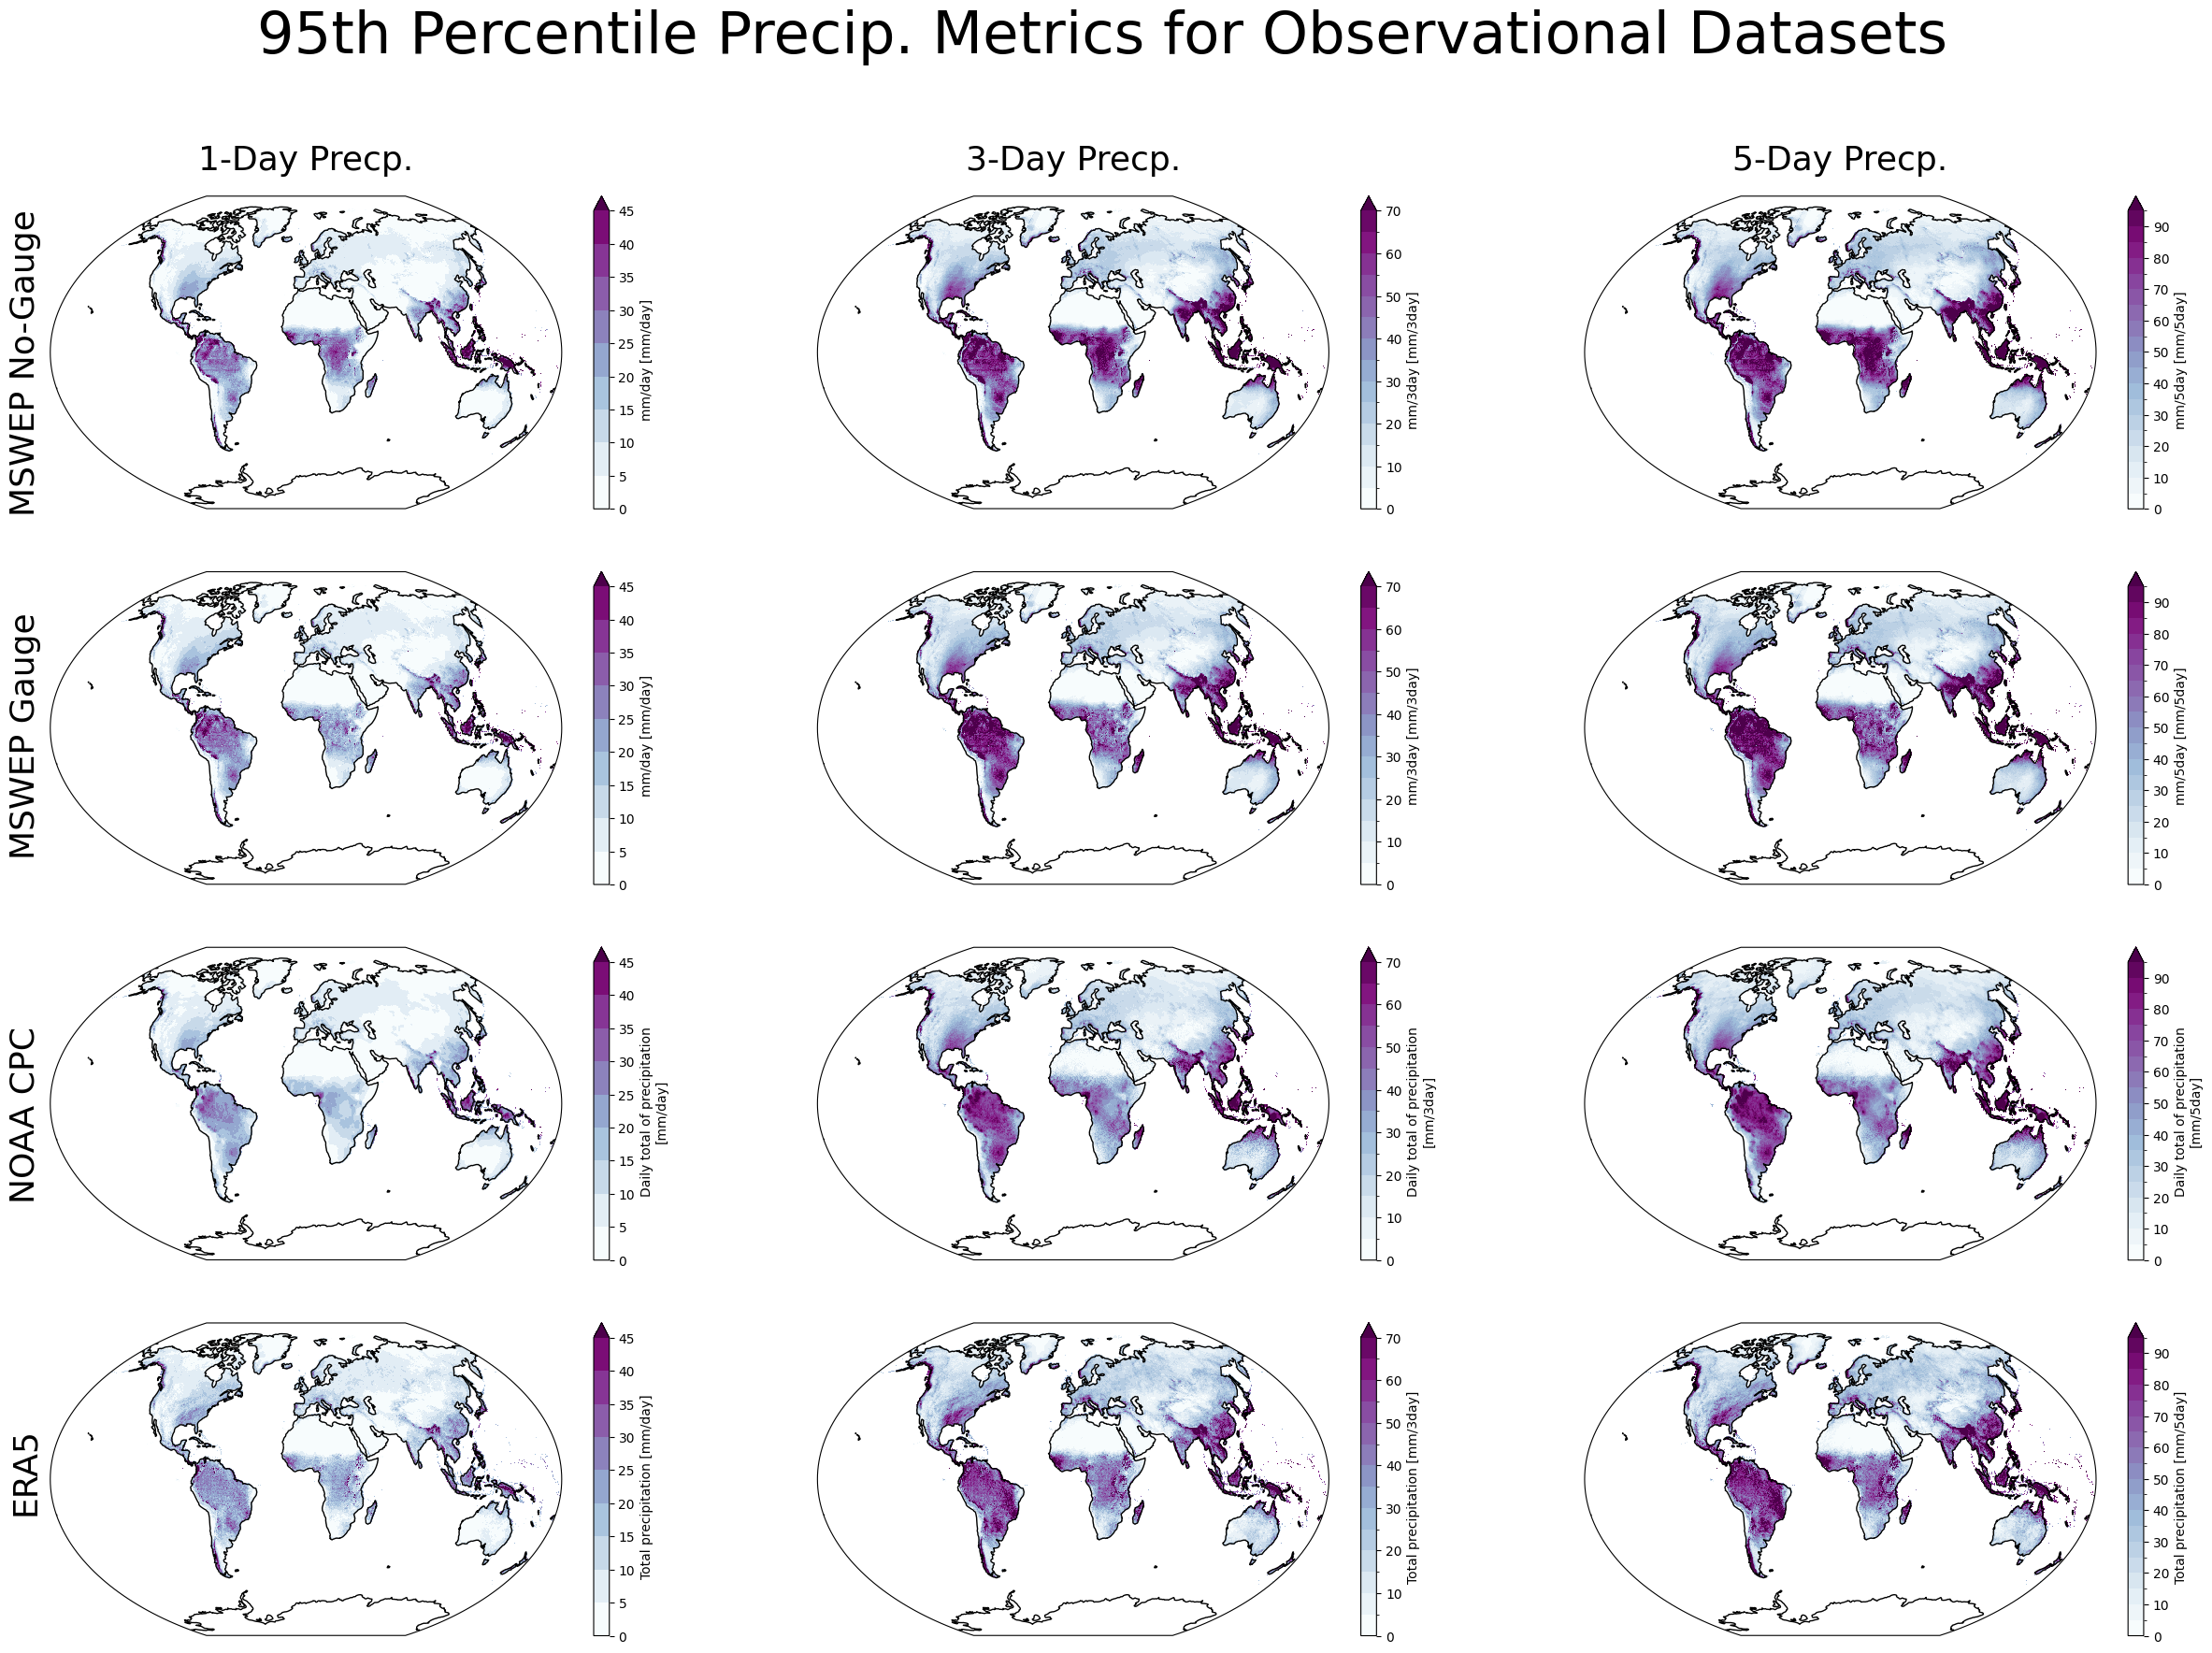

In [2]:
%%time
%matplotlib inline 
####################################
##         Quantiles Map          ##
####################################

proj = WinkelTripel()
transform = ccrs.PlateCarree()
cmap = "BuPu"
quantile = 0.95

one_day_levels = np.arange(0, 50, 5)
three_day_levels = np.arange(0, 75, 5)
five_day_levels = np.arange(0, 100, 5)

cb_labels = [
    "mm/day", "mm/3day", "mm/5day"
]

f, axes = plt.subplots(4, 3, figsize=(30, 20), facecolor='w', subplot_kw=dict(projection=proj))

mswep_ng_quants["one_day_pr"].sel(quantile=quantile).rename(cb_labels[0]).plot.imshow(ax=axes[0,0], levels=one_day_levels, transform=transform, cmap=cmap)
mswep_ng_quants["three_day_pr"].sel(quantile=quantile).rename(cb_labels[1]).plot.imshow(ax=axes[0,1], levels=three_day_levels, transform=transform, cmap=cmap)
mswep_ng_quants["five_day_pr"].sel(quantile=quantile).rename(cb_labels[2]).plot.imshow(ax=axes[0,2], levels=five_day_levels, transform=transform, cmap=cmap)

mswep_g_quants["one_day_pr"].sel(quantile=quantile).rename(cb_labels[0]).plot.imshow(ax=axes[1,0], levels=one_day_levels, transform=transform, cmap=cmap)
mswep_g_quants["three_day_pr"].sel(quantile=quantile).rename(cb_labels[1]).plot.imshow(ax=axes[1,1], levels=three_day_levels, transform=transform, cmap=cmap)
mswep_g_quants["five_day_pr"].sel(quantile=quantile).rename(cb_labels[2]).plot.imshow(ax=axes[1,2], levels=five_day_levels, transform=transform, cmap=cmap)

noaa_cpc_quants["one_day_pr"].sel(quantile=quantile).rename(cb_labels[0]).plot.imshow(ax=axes[2,0], levels=one_day_levels, transform=transform, cmap=cmap)
noaa_cpc_quants["three_day_pr"].sel(quantile=quantile).rename(cb_labels[1]).plot.imshow(ax=axes[2,1], levels=three_day_levels, transform=transform, cmap=cmap)
noaa_cpc_quants["five_day_pr"].sel(quantile=quantile).rename(cb_labels[2]).plot.imshow(ax=axes[2,2], levels=five_day_levels, transform=transform, cmap=cmap)

era5_quants["one_day_pr"].sel(quantile=quantile).rename(cb_labels[0]).plot.imshow(ax=axes[3,0], levels=one_day_levels, transform=transform, cmap=cmap)
era5_quants["three_day_pr"].sel(quantile=quantile).rename(cb_labels[1]).plot.imshow(ax=axes[3,1], levels=three_day_levels, transform=transform, cmap=cmap)
era5_quants["five_day_pr"].sel(quantile=quantile).rename(cb_labels[2]).plot.imshow(ax=axes[3,2], levels=five_day_levels, transform=transform, cmap=cmap)

for i in range(axes.shape[0]):
    for j in range(axes.shape[1]):
        axes[i, j].coastlines()
        axes[i, j].set_title("")

fz = 26
pad = 20
axes[0, 0].set_title("1-Day Precp.", fontsize=fz, pad=pad)
axes[0, 1].set_title("3-Day Precp.", fontsize=fz, pad=pad)
axes[0, 2].set_title("5-Day Precp.", fontsize=fz, pad=pad)
axes[0, 0].text(-0.08, 0, "MSWEP No-Gauge", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)
axes[1, 0].text(-0.08, -1.1, "MSWEP Gauge", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)
axes[2, 0].text(-0.08, -2.2, "NOAA CPC", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)
axes[3, 0].text(-0.08, -3.2, "ERA5", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)

f.suptitle(f"{int(quantile*100)}th Percentile Precip. Metrics for Observational Datasets", fontsize=45)

### Figure 1:

## Task 3: Generating the Median and 5th percentile maps

1. Copy and paste the block of code that you used to generate the 95th percentile maps into two new code blocks. In each of the new code blocks, modify the `quantile` variable to output the median or the 5th percentile values. You will likely also need to play around with the colorbar ranges. These are set in the `one_day_levels`, `three_day_levels`, and `five_day_levels` variables near the top of the code block. For example, `one_day_levels = np.arange(0, 50, 5)` creates a colobar that starts at `0`, ends at `50`, and is broken up into increments of `5`. Change the numbers in the parentheses to choose different start, end, and increments that work for each figure. You can decide if you think the colorbar ranges should be the same for each metric or should vary.

2. For each of the 5th and median figures generated, add a markdown cell below it (Insert --> Cell Below, then Cell-->Cell Type-->Markdown) and add a figure caption similar to what you generated for the 95th percentile figure.

# Step 3: Map the Trends

The below block of code maps the 30-year trends in each of the 3 metrics for each of the 4 observational datasets.

The 30-year trends are calculated by performing a linear regression through the **annual maximum** value of each metric. The maps show the rate of change in each year's wettest multi-day event over the 30 year period of observations.

## Task 4: Add a Figure Caption
Below the trend figure is a Markdown cell with the start of a figure caption. Use the best practices discussed in class to write a complete figure caption.

CPU times: user 15.3 s, sys: 563 ms, total: 15.9 s
Wall time: 15.9 s


Text(0.5, 0.98, 'Annual Trends of Precip. Metrics for Observational Datasets')

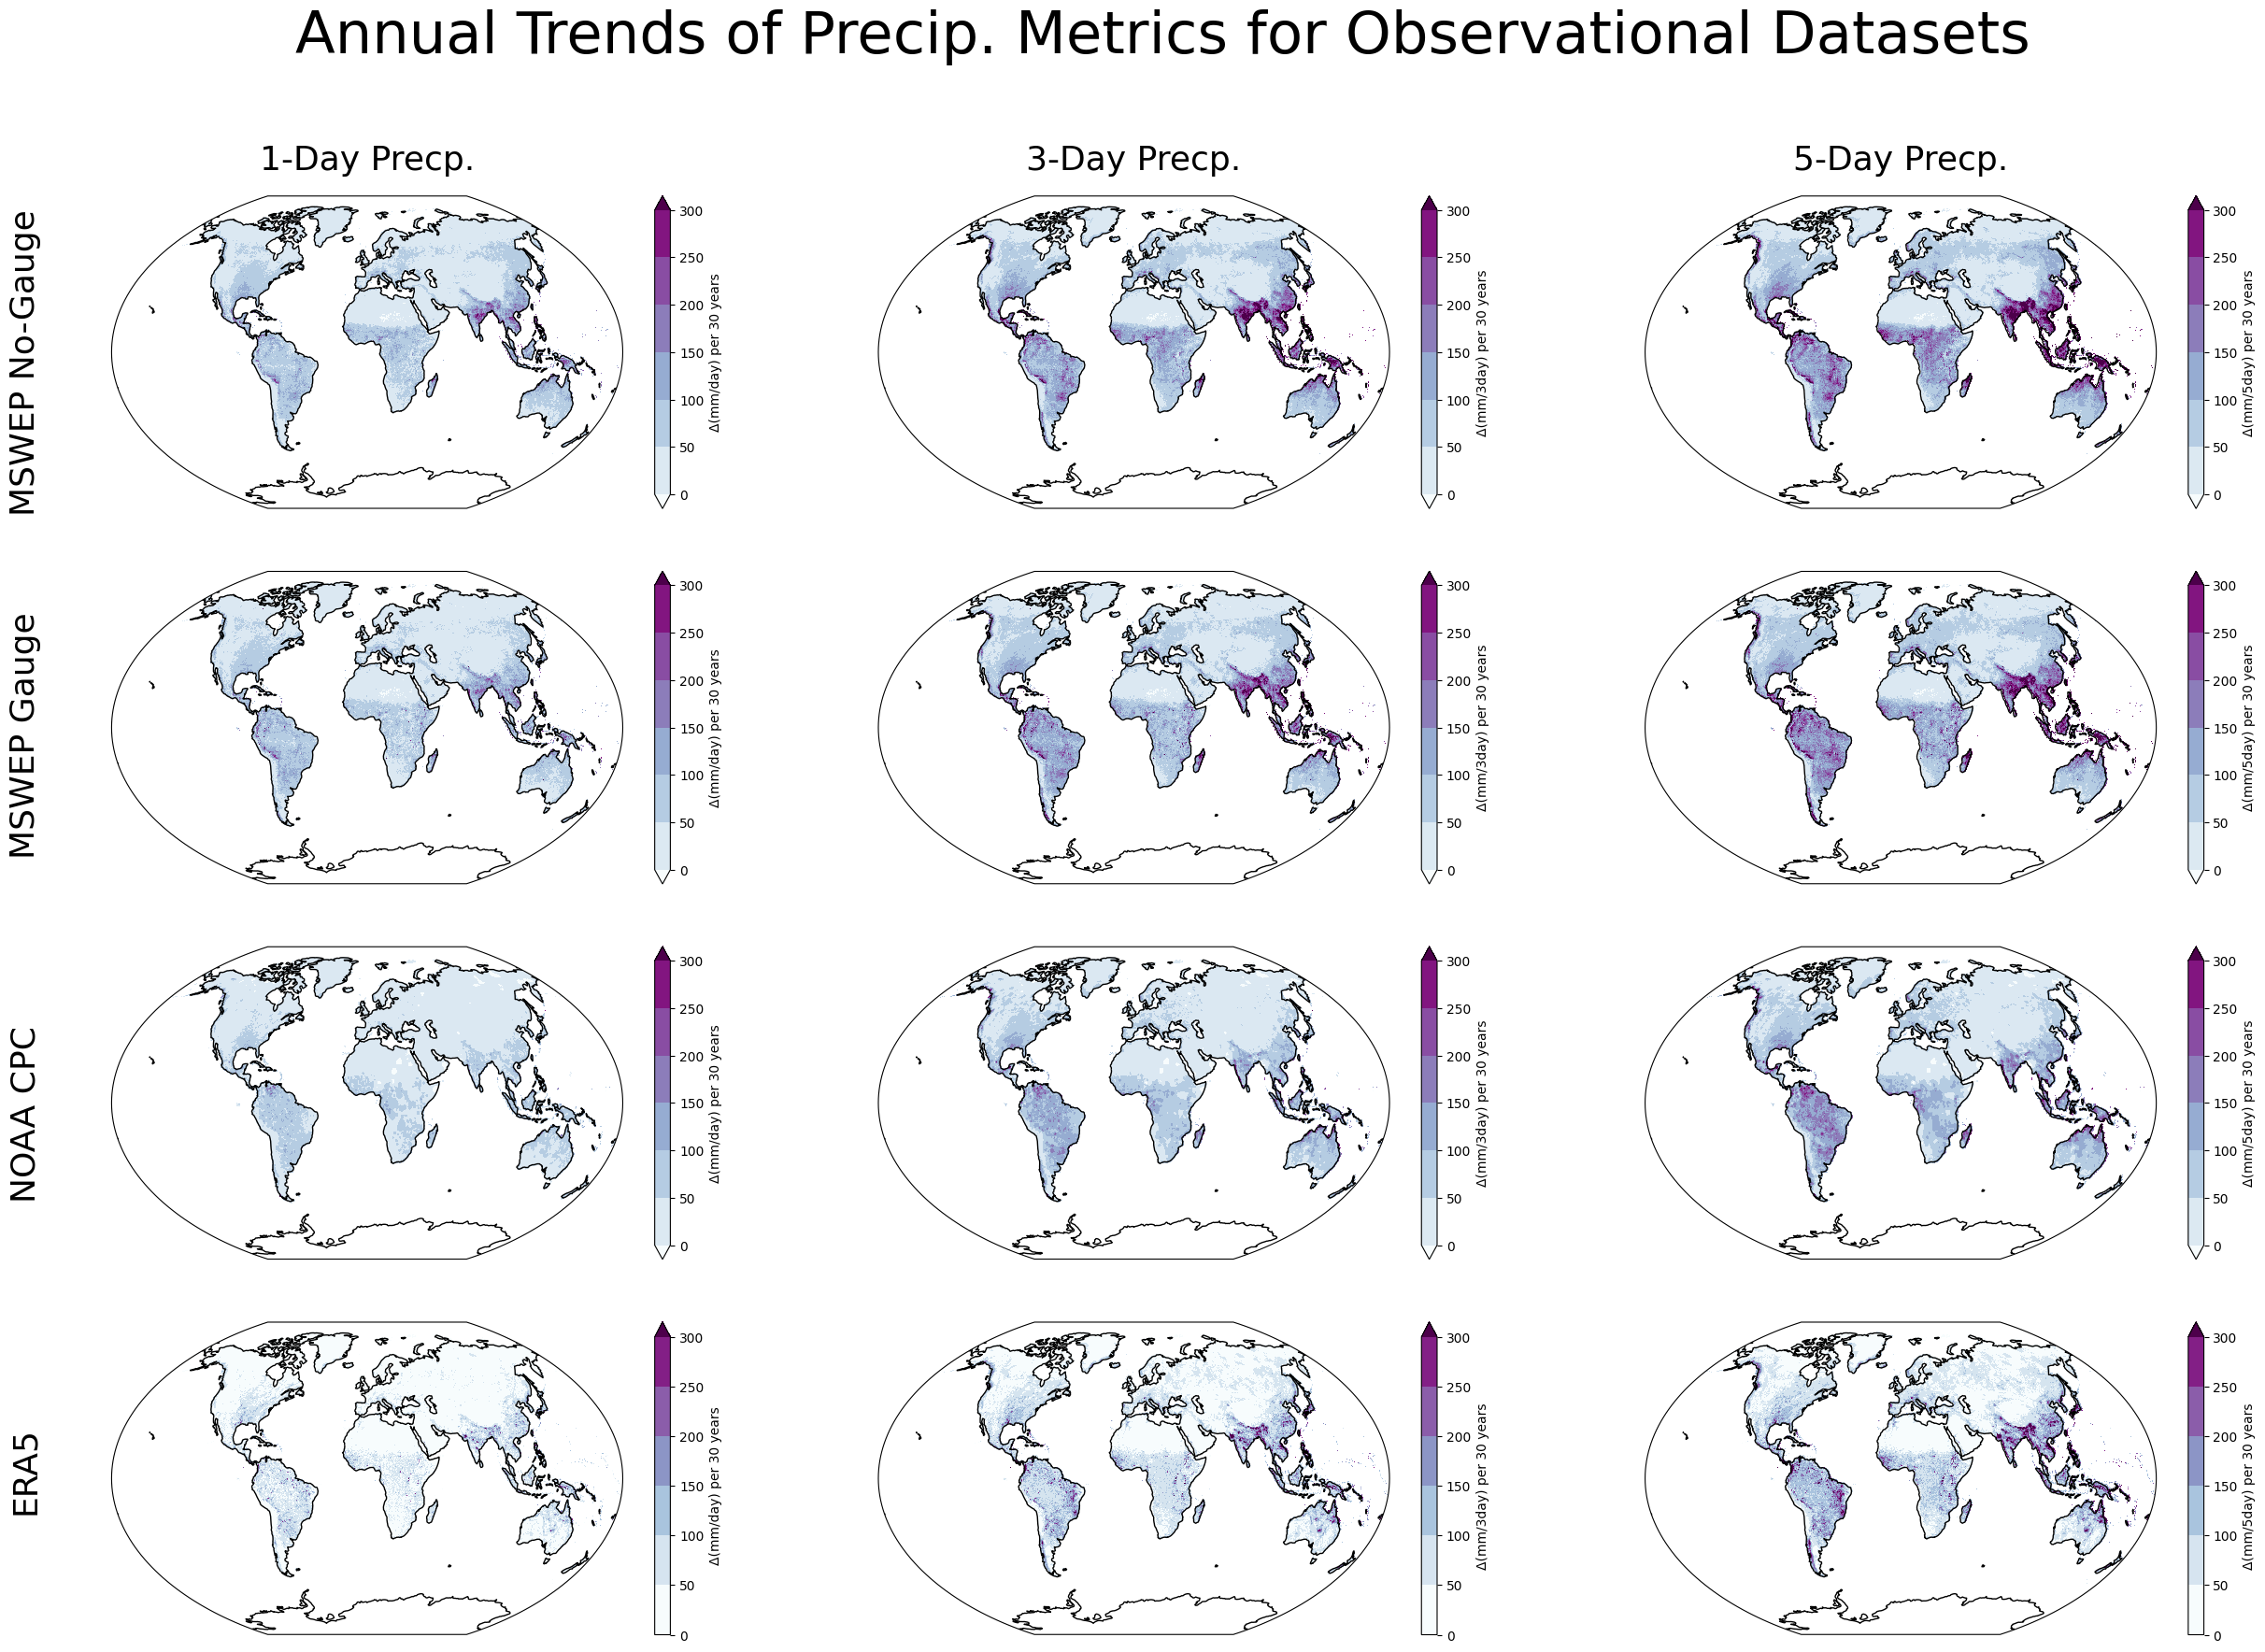

In [6]:
%%time
%matplotlib inline
####################################
##           Trends Map           ##
####################################

proj = WinkelTripel()
transform = ccrs.PlateCarree()
cmap = "BuPu"

one_day_levels = np.arange(0, 301, 50)
three_day_levels = np.arange(0, 301, 50)
five_day_levels = np.arange(0, 301, 50)
robust = True

cb_labels = [
    "Δ(mm/day) per 30 years", "Δ(mm/3day) per 30 years", "Δ(mm/5day) per 30 years"
]

f, axes = plt.subplots(4, 3, figsize=(30, 20), facecolor='w', subplot_kw=dict(projection=proj))

mswep_ng_trends["one_day_pr_polyfit_coefficients"].rename(cb_labels[0]).sel(degree=0).plot.imshow(ax=axes[0,0], levels=one_day_levels, transform=transform, cmap=cmap, robust=robust)
mswep_ng_trends["three_day_pr_polyfit_coefficients"].rename(cb_labels[1]).sel(degree=0).plot.imshow(ax=axes[0,1], levels=three_day_levels, transform=transform, cmap=cmap, robust=robust)
mswep_ng_trends["five_day_pr_polyfit_coefficients"].rename(cb_labels[2]).sel(degree=0).plot.imshow(ax=axes[0,2], levels=five_day_levels, transform=transform, cmap=cmap, robust=robust)

mswep_g_trends["one_day_pr_polyfit_coefficients"].rename(cb_labels[0]).sel(degree=0).plot.imshow(ax=axes[1,0], levels=one_day_levels, transform=transform, cmap=cmap, robust=robust)
mswep_g_trends["three_day_pr_polyfit_coefficients"].rename(cb_labels[1]).sel(degree=0).plot.imshow(ax=axes[1,1], levels=three_day_levels, transform=transform, cmap=cmap, robust=robust)
mswep_g_trends["five_day_pr_polyfit_coefficients"].rename(cb_labels[2]).sel(degree=0).plot.imshow(ax=axes[1,2], levels=five_day_levels, transform=transform, cmap=cmap, robust=robust)

noaa_cpc_trends["one_day_pr_polyfit_coefficients"].rename(cb_labels[0]).sel(degree=0).plot.imshow(ax=axes[2,0], levels=one_day_levels, transform=transform, cmap=cmap, robust=robust)
noaa_cpc_trends["three_day_pr_polyfit_coefficients"].rename(cb_labels[1]).sel(degree=0).plot.imshow(ax=axes[2,1], levels=three_day_levels, transform=transform, cmap=cmap, robust=robust)
noaa_cpc_trends["five_day_pr_polyfit_coefficients"].rename(cb_labels[2]).sel(degree=0).plot.imshow(ax=axes[2,2], levels=five_day_levels, transform=transform, cmap=cmap, robust=robust)

era5_trends["one_day_pr_polyfit_coefficients"].rename(cb_labels[0]).sel(degree=0).plot.imshow(ax=axes[3,0], levels=one_day_levels, transform=transform, cmap=cmap, robust=robust)
era5_trends["three_day_pr_polyfit_coefficients"].rename(cb_labels[1]).sel(degree=0).plot.imshow(ax=axes[3,1], levels=three_day_levels, transform=transform, cmap=cmap, robust=robust)
era5_trends["five_day_pr_polyfit_coefficients"].rename(cb_labels[2]).sel(degree=0).plot.imshow(ax=axes[3,2], levels=five_day_levels, transform=transform, cmap=cmap, robust=robust)

for i in range(axes.shape[0]):
    for j in range(axes.shape[1]):
        axes[i, j].coastlines()
        axes[i, j].set_title("")

fz = 26
pad = 20
axes[0, 0].set_title("1-Day Precp.", fontsize=fz, pad=pad)
axes[0, 1].set_title("3-Day Precp.", fontsize=fz, pad=pad)
axes[0, 2].set_title("5-Day Precp.", fontsize=fz, pad=pad)
axes[0, 0].text(-0.2, 0, "MSWEP No-Gauge", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)
axes[1, 0].text(-0.2, -1.1, "MSWEP Gauge", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)
axes[2, 0].text(-0.2, -2.2, "NOAA CPC", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)
axes[3, 0].text(-0.2, -3.2, "ERA5", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)

f.suptitle(f"Annual Trends of Precip. Metrics for Observational Datasets", fontsize=45)

### Figure 4:

# Step 4: Identifying regional behaviors

In the global maps, it can be difficult to identify what is happening in particular regions. It's also difficult to tell that the datasets have different spatial resolutions. 

The below code block contains a function that lets you set latitude and longitude bounds to define a region. Currently the latitude and longitude bounds are set for a region of Texas stretching from Austin to the gulf coast. The `lat_min` value is the southern boundaryin degrees latitude, the `lat_max` value is the northern boundary in degrees latitude, the `lon_min` is the eastern boundary in degrees longitude, and the `lon_max` is the western boundary in degrees longitude (where negative longitude means west of the prime meridian).

In [4]:
def crop_ds(da):
    lat_min, lat_max = 28, 36
    lon_min, lon_max = -100, -90
    return da.sel(lat=slice(lat_max, lat_min)).sel(lon=slice(lon_min, lon_max))

### Task 5: Map a region of interest

The code block below calls the `crop_ds` function to create regional maps of the 95th percentile of each of the metrics and each of the observational datasets for the region that is defined above in the `crop_ds` function.

1. Choose a region of interest and figure out its latitude and longtitude bounds using Google Maps: maps.google.com
2. Modify the `lat_min`, `lat_max`, `lon_min`, and `lon_max` values in the `crop_ds` function above to define your region, and **re-run the `crop_ds` code block**
3. **Rerun the map code block below** to generate the map for your new region.
4. Below the figure is a Markdown cell with the start of a figure caption. Use the best practices discussed in class to write a complete figure caption, making sure to include the following:
   - Your chosen region and its latitude and longitude bounds
   - A discussion of differences between the observational datasets in the spatial distribution and magnitude of the values across your region for each metric

CPU times: user 193 ms, sys: 13 ms, total: 206 ms
Wall time: 212 ms


Text(0.5, 0.98, '95th Percentile Precip. Metrics for Observational Datasets')

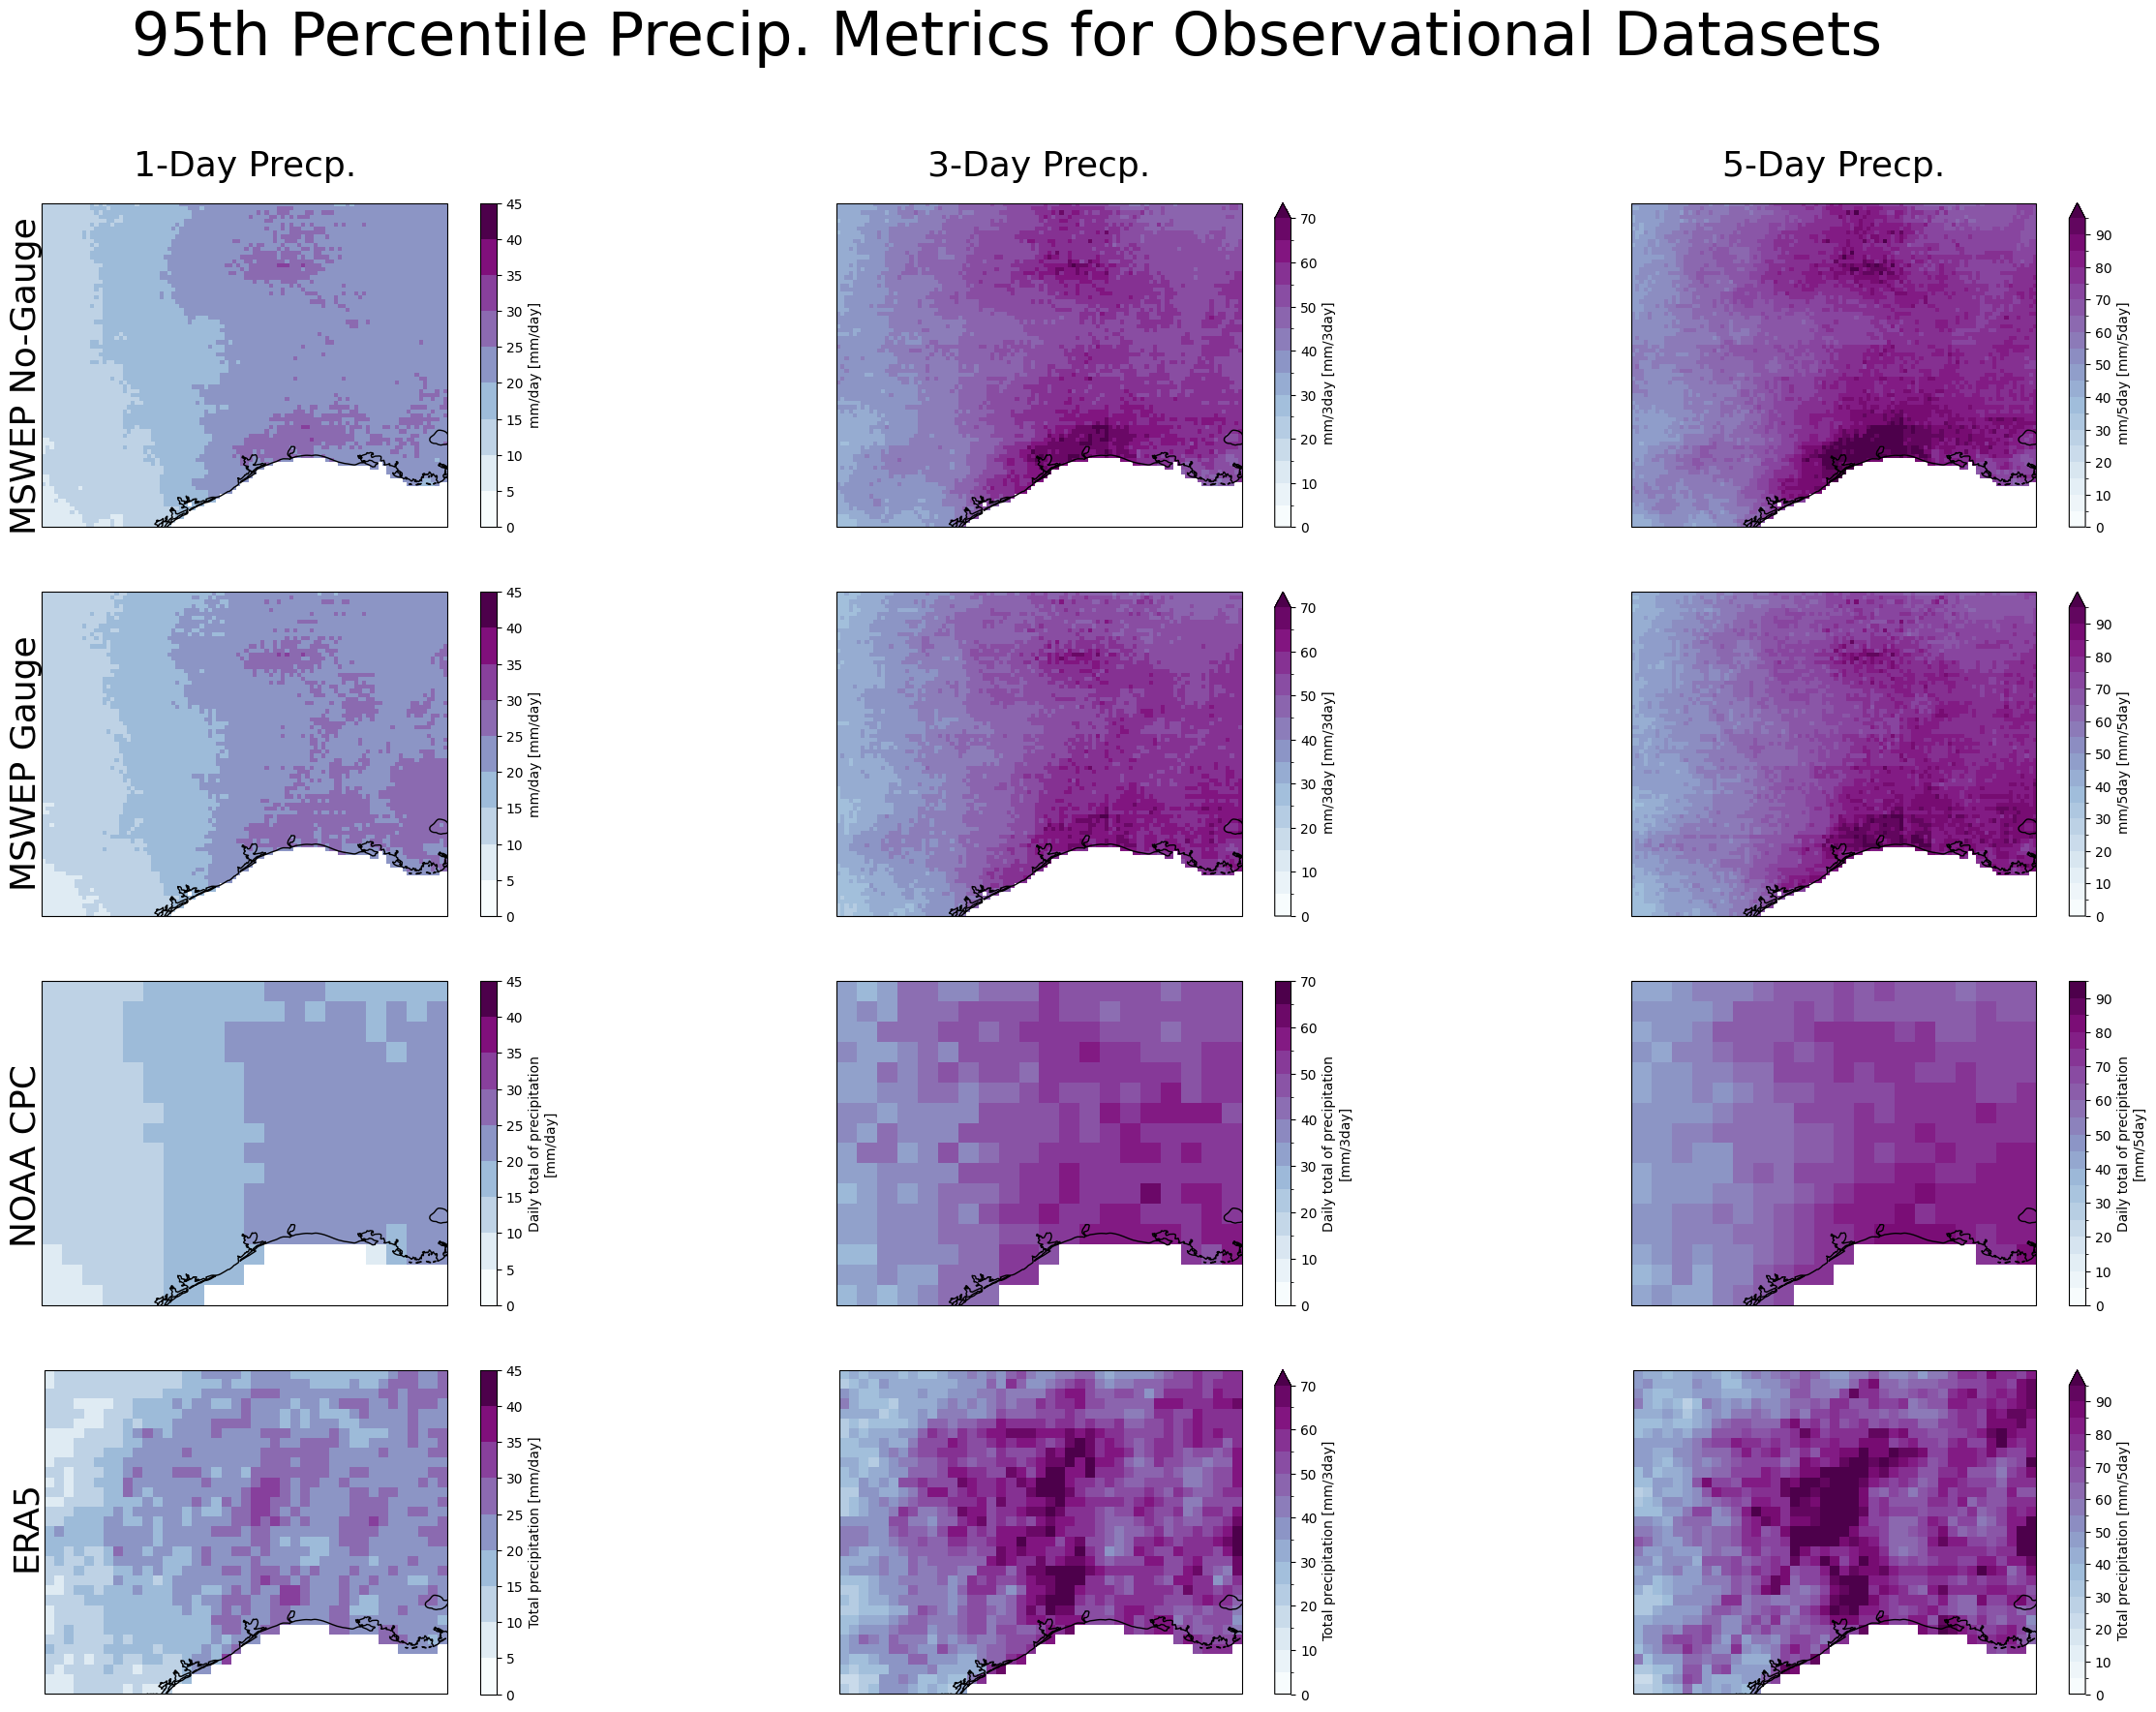

In [5]:
%%time
%matplotlib inline 
####################################
##         Quantiles Map          ##
####################################

proj = ccrs.PlateCarree()
transform = ccrs.PlateCarree()
cmap = "BuPu"
quantile = 0.95

one_day_levels = np.arange(0, 50, 5)
three_day_levels = np.arange(0, 75, 5)
five_day_levels = np.arange(0, 100, 5)

cb_labels = [
    "mm/day", "mm/3day", "mm/5day"
]

f, axes = plt.subplots(4, 3, figsize=(30, 20), facecolor='w', subplot_kw=dict(projection=proj))

crop_ds(mswep_ng_quants)["one_day_pr"].sel(quantile=quantile).rename(cb_labels[0]).plot.imshow(ax=axes[0,0], levels=one_day_levels, transform=transform, cmap=cmap)
crop_ds(mswep_ng_quants)["three_day_pr"].sel(quantile=quantile).rename(cb_labels[1]).plot.imshow(ax=axes[0,1], levels=three_day_levels, transform=transform, cmap=cmap)
crop_ds(mswep_ng_quants)["five_day_pr"].sel(quantile=quantile).rename(cb_labels[2]).plot.imshow(ax=axes[0,2], levels=five_day_levels, transform=transform, cmap=cmap)

crop_ds(mswep_g_quants)["one_day_pr"].sel(quantile=quantile).rename(cb_labels[0]).plot.imshow(ax=axes[1,0], levels=one_day_levels, transform=transform, cmap=cmap)
crop_ds(mswep_g_quants)["three_day_pr"].sel(quantile=quantile).rename(cb_labels[1]).plot.imshow(ax=axes[1,1], levels=three_day_levels, transform=transform, cmap=cmap)
crop_ds(mswep_g_quants)["five_day_pr"].sel(quantile=quantile).rename(cb_labels[2]).plot.imshow(ax=axes[1,2], levels=five_day_levels, transform=transform, cmap=cmap)

crop_ds(noaa_cpc_quants)["one_day_pr"].sel(quantile=quantile).rename(cb_labels[0]).plot.imshow(ax=axes[2,0], levels=one_day_levels, transform=transform, cmap=cmap)
crop_ds(noaa_cpc_quants)["three_day_pr"].sel(quantile=quantile).rename(cb_labels[1]).plot.imshow(ax=axes[2,1], levels=three_day_levels, transform=transform, cmap=cmap)
crop_ds(noaa_cpc_quants)["five_day_pr"].sel(quantile=quantile).rename(cb_labels[2]).plot.imshow(ax=axes[2,2], levels=five_day_levels, transform=transform, cmap=cmap)

crop_ds(era5_quants)["one_day_pr"].sel(quantile=quantile).rename(cb_labels[0]).plot.imshow(ax=axes[3,0], levels=one_day_levels, transform=transform, cmap=cmap)
crop_ds(era5_quants)["three_day_pr"].sel(quantile=quantile).rename(cb_labels[1]).plot.imshow(ax=axes[3,1], levels=three_day_levels, transform=transform, cmap=cmap)
crop_ds(era5_quants)["five_day_pr"].sel(quantile=quantile).rename(cb_labels[2]).plot.imshow(ax=axes[3,2], levels=five_day_levels, transform=transform, cmap=cmap)

for i in range(axes.shape[0]):
    for j in range(axes.shape[1]):
        axes[i, j].coastlines()
        axes[i, j].set_title("")

fz = 26
pad = 20
axes[0, 0].set_title("1-Day Precp.", fontsize=fz, pad=pad)
axes[0, 1].set_title("3-Day Precp.", fontsize=fz, pad=pad)
axes[0, 2].set_title("5-Day Precp.", fontsize=fz, pad=pad)
axes[0, 0].text(-0.08, 0, "MSWEP No-Gauge", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)
axes[1, 0].text(-0.08, -1.1, "MSWEP Gauge", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)
axes[2, 0].text(-0.08, -2.2, "NOAA CPC", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)
axes[3, 0].text(-0.08, -3.2, "ERA5", rotation=90, transform=axes[0, 0].transAxes, fontsize=fz)

f.suptitle(f"{int(quantile*100)}th Percentile Precip. Metrics for Observational Datasets", fontsize=45)

### Figure 5:

# Only graduate students are required to complete the section below. Undergraduate students may complete it for an additional 2 points of extra credit, allowing you to earn up to 7/5 points.

# Step 5: Get creative! 

There are a number of different questions that might arise as you look at the plots above, but that are difficult to fully address with the maps we've made. For example, are the trends in some places bigger just because the amount of rainfall there is bigger? Is the growth in cumulative totals from 1-day to 3-day to 5-day rainfall the same everywhere on the globe, or do some places see more of an amplification of rainfall in the longer events than others?


## Task 6: Design your own analysis

1. Identify and describe (in a markdown box) a research question, similar to the examples above, that you are trying to explore further in the data.
2. Based on the code that we've provided throughout this notebook, design your own new analysis and write the code to generate a map of that analysis (if your analysis is better visualized in something other than a map, you are welcome to attempt that). 
3. Add a descriptive figure caption to your analysis that describes the methodology you followed in your analysis and the answer to your research question captured by the resulting figure.